Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0197
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0118
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0115
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0112
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0112
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


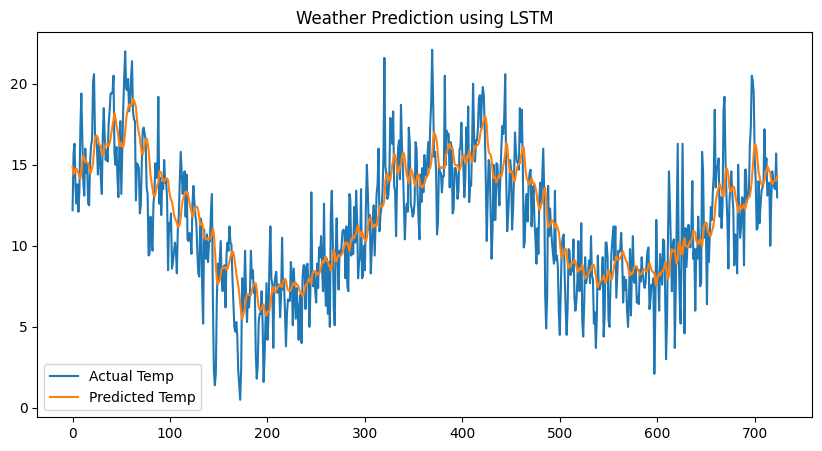

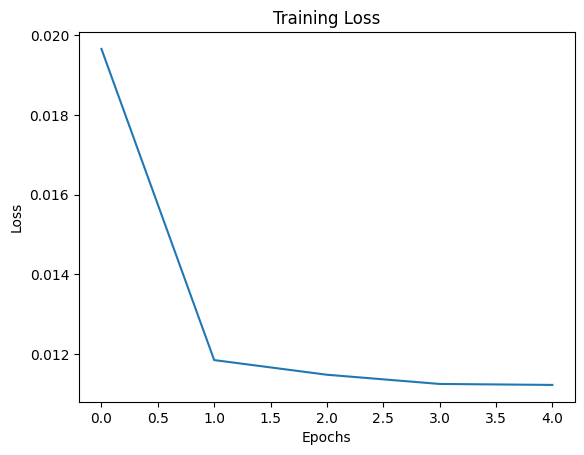

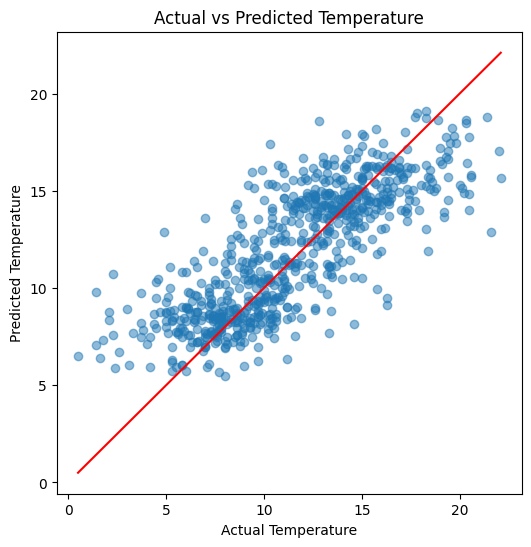

In [ ]:
# ================================
# LSTM for Weather Prediction
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# 1. Load Dataset (daily minimum temperatures dataset)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

# 2. Use Temperature column
data = df[['Temp']]

# 3. Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# 4. Create Sequences
def create_dataset(data, time_step=30):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)

# 5. Train-Test Split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. Reshape
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# 7. Build Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(30,1)),
    LSTM(50),
    Dense(1)
])

# 8. Compile
model.compile(optimizer='adam', loss='mean_squared_error')

# 9. Train
history = model.fit(X_train, y_train, epochs=5, batch_size=32)

# 10. Predict
pred = model.predict(X_test)

# 11. Inverse Transform
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# 12. Plot Predictions
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Temp')
plt.plot(pred, label='Predicted Temp')
plt.legend()
plt.title("Weather Prediction using LSTM")
plt.show()

# 13. Loss Graph
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# =========================================
# Actual vs Predicted Scatter Plot
# =========================================

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, pred, alpha=0.5)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")

# Perfect prediction line
plt.plot([min(y_test_actual), max(y_test_actual)],
         [min(y_test_actual), max(y_test_actual)],
         color='red')

plt.show()